# Uber Ride Analytics — End-to-End Exploratory Data Analysis

### Business-focused analysis of 150,000 ride bookings

**Objective:**  
Analyze ride demand, fulfillment, cancellations, operational performance, revenue economics, and customer experience to identify actionable business opportunities.

**Tools:** Python, Pandas, NumPy, Matplotlib

## Table of Contents

1. [Executive Business Overview](#1-executive-business-overview)
2. [Demand & Peak Period Analysis](#2-demand--peak-period-analysis)
3. [Fulfillment & Cancellation Analysis](#3-fulfillment--cancellation-analysis)
4. [Vehicle Performance Analysis](#4-vehicle-performance-analysis)
5. [Location & Operational Risk Analysis](#5-location--operational-risk-analysis)
6. [Revenue & Trip Economics](#6-revenue--trip-economics)
7. [Customer Experience & Ratings](#7-customer-experience--ratings)
8. [Key Business Insights](#7-key-business-insights)
9. [Business Recommendations](#8-business-recommendations)
10. [Conclusion](#9-conclusion)

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("ncr_ride_bookings.csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

print("\nFIRST 5 ROWS")
display(df.head())

print("\nNUMERICAL SUMMARY")
display(df.describe().T)

DATASET OVERVIEW
Rows: 150,000
Columns: 21

COLUMN NAMES
['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']

DATA TYPES
Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI



NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Avg VTAT,139500.0,8.456352,3.773564,2.0,5.30,8.30,11.30,20.0
Avg CTAT,102000.0,29.149636,8.902577,10.0,21.60,28.80,36.80,45.0
Cancelled Rides by Customer,10500.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0
Cancelled Rides by Driver,27000.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0
Incomplete Rides,9000.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0
Booking Value,102000.0,508.295912,395.805774,50.0,234.00,414.00,689.00,4277.0
Ride Distance,102000.0,24.637012,14.002138,1.0,12.46,23.72,36.82,50.0
Driver Ratings,93000.0,4.230992,0.436871,3.0,4.10,4.30,4.60,5.0
Customer Rating,93000.0,4.404584,0.437819,3.0,4.20,4.50,4.80,5.0


In [2]:
# ============================================
# DATA CLEANING & FEATURE ENGINEERING
# ============================================

# Work on a copy so the raw dataset remains untouched
df_clean = df.copy()

# Convert Date and Time to proper datetime formats
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
df_clean["Time"] = pd.to_datetime(
    df_clean["Time"], format="%H:%M:%S", errors="coerce"
).dt.time

# Create useful time-based features
df_clean["Hour"] = pd.to_datetime(
    df_clean["Time"].astype(str),
    format="%H:%M:%S",
    errors="coerce"
).dt.hour

df_clean["Day"] = df_clean["Date"].dt.day
df_clean["Day of Week"] = df_clean["Date"].dt.day_name()
df_clean["Month"] = df_clean["Date"].dt.month_name()
df_clean["Month Number"] = df_clean["Date"].dt.month

df_clean["Is Weekend"] = df_clean["Date"].dt.dayofweek >= 5

# Create revenue-per-kilometre metric
df_clean["Revenue per KM"] = np.where(
    (df_clean["Ride Distance"] > 0) & (df_clean["Booking Value"].notna()),
    df_clean["Booking Value"] / df_clean["Ride Distance"],
    np.nan
)

# Clean text columns
text_columns = [
    "Booking Status",
    "Vehicle Type",
    "Pickup Location",
    "Drop Location",
    "Payment Method",
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason"
]

for col in text_columns:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# Create simple status indicators
df_clean["Is Completed"] = (
    df_clean["Booking Status"] == "Completed"
).astype(int)

df_clean["Is Customer Cancelled"] = (
    df_clean["Booking Status"] == "Cancelled by Customer"
).astype(int)

df_clean["Is Driver Cancelled"] = (
    df_clean["Booking Status"] == "Cancelled by Driver"
).astype(int)

df_clean["Is Incomplete"] = (
    df_clean["Booking Status"] == "Incomplete"
).astype(int)

# Basic validation
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nMissing values in key engineered columns:")
print(
    df_clean[
        ["Hour", "Day of Week", "Month", "Revenue per KM"]
    ].isna().sum()
)

print("\nBooking Status distribution:")
display(
    df_clean["Booking Status"]
    .value_counts(dropna=False)
    .to_frame("Bookings")
)

print("\nWeekend vs Weekday:")
display(
    df_clean["Is Weekend"]
    .value_counts()
    .rename(index={False: "Weekday", True: "Weekend"})
    .to_frame("Bookings")
)

print("\nCleaned dataset preview:")
display(
    df_clean[
        [
            "Date",
            "Time",
            "Booking Status",
            "Vehicle Type",
            "Booking Value",
            "Ride Distance",
            "Hour",
            "Day of Week",
            "Month",
            "Is Weekend",
            "Revenue per KM"
        ]
    ].head()
)

Original shape: (150000, 21)
Cleaned shape: (150000, 32)

Missing values in key engineered columns:
Hour                  0
Day of Week           0
Month                 0
Revenue per KM    48000
dtype: int64

Booking Status distribution:


,Bookings
Booking Status,
Completed,93000
Cancelled by Driver,27000
No Driver Found,10500
Cancelled by Customer,10500
Incomplete,9000



Weekend vs Weekday:


,Bookings
Is Weekend,
Weekday,107060
Weekend,42940



Cleaned dataset preview:


,Date,Time,Booking Status,Vehicle Type,Booking Value,Ride Distance,Hour,Day of Week,Month,Is Weekend,Revenue per KM
0,2024-03-23,12:29:38,No Driver Found,eBike,NaN,NaN,12,Saturday,March,True,NaN
1,2024-11-29,18:01:39,Incomplete,Go Sedan,237.0,5.73,18,Friday,November,False,41.361257
2,2024-08-23,08:56:10,Completed,Auto,627.0,13.58,8,Friday,August,False,46.170839
3,2024-10-21,17:17:25,Completed,Premier Sedan,416.0,34.02,17,Monday,October,False,12.228101
4,2024-09-16,22:08:00,Completed,Bike,737.0,48.21,22,Monday,September,False,15.287285


## 1. Executive Business Overview

Before diving into individual factors, we first establish the overall health of the ride-booking business through key operational, financial, and customer-experience KPIs.

In [3]:
# ============================================
# EXECUTIVE BUSINESS KPIs
# ============================================

total_bookings = len(df_clean)

completed_rides = (df_clean["Booking Status"] == "Completed").sum()
customer_cancelled = (df_clean["Booking Status"] == "Cancelled by Customer").sum()
driver_cancelled = (df_clean["Booking Status"] == "Cancelled by Driver").sum()
no_driver_found = (df_clean["Booking Status"] == "No Driver Found").sum()
incomplete_rides = (df_clean["Booking Status"] == "Incomplete").sum()

completion_rate = completed_rides / total_bookings * 100
customer_cancel_rate = customer_cancelled / total_bookings * 100
driver_cancel_rate = driver_cancelled / total_bookings * 100
no_driver_rate = no_driver_found / total_bookings * 100
incomplete_rate = incomplete_rides / total_bookings * 100

completed_df = df_clean[df_clean["Booking Status"] == "Completed"]

total_revenue = completed_df["Booking Value"].sum()
avg_booking_value = completed_df["Booking Value"].mean()
avg_ride_distance = completed_df["Ride Distance"].mean()
avg_revenue_per_km = completed_df["Revenue per KM"].mean()

avg_driver_rating = completed_df["Driver Ratings"].mean()
avg_customer_rating = completed_df["Customer Rating"].mean()

kpis = pd.DataFrame({
    "Metric": [
        "Total Bookings",
        "Completed Rides",
        "Completion Rate",
        "Customer Cancellation Rate",
        "Driver Cancellation Rate",
        "No Driver Found Rate",
        "Incomplete Ride Rate",
        "Total Revenue (Completed)",
        "Average Booking Value",
        "Average Ride Distance (KM)",
        "Average Revenue per KM",
        "Average Driver Rating",
        "Average Customer Rating"
    ],
    "Value": [
        total_bookings,
        completed_rides,
        completion_rate,
        customer_cancel_rate,
        driver_cancel_rate,
        no_driver_rate,
        incomplete_rate,
        total_revenue,
        avg_booking_value,
        avg_ride_distance,
        avg_revenue_per_km,
        avg_driver_rating,
        avg_customer_rating
    ]
})

display(kpis)


,Metric,Value
0,Total Bookings,1.500000e+05
1,Completed Rides,9.300000e+04
2,Completion Rate,6.200000e+01
3,Customer Cancellation Rate,7.000000e+00
4,Driver Cancellation Rate,1.800000e+01
5,No Driver Found Rate,7.000000e+00
6,Incomplete Ride Rate,6.000000e+00
7,Total Revenue (Completed),4.726057e+07
8,Average Booking Value,5.081782e+02
9,Average Ride Distance (KM),2.600049e+01


### Business Snapshot

The dataset contains 150,000 ride-booking records. The analysis focuses on demand, fulfillment, operational reliability, revenue performance, and customer experience.

## 2. Demand & Time Analysis

Understanding when customers book rides helps Uber align driver availability with demand, reduce unmet demand, and improve ride completion.

In [4]:
# ============================================
# DEMAND & TIME ANALYSIS
# ============================================

# Hourly demand
hourly_demand = (
    df_clean.groupby("Hour")
    .size()
    .reset_index(name="Bookings")
    .sort_values("Hour")
)

# Day-of-week demand
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_demand = (
    df_clean.groupby("Day of Week")
    .size()
    .reindex(day_order)
    .reset_index(name="Bookings")
)

# Monthly demand
monthly_demand = (
    df_clean.groupby(["Month Number", "Month"])
    .size()
    .reset_index(name="Bookings")
    .sort_values("Month Number")
)

# Weekday vs weekend
weekend_demand = (
    df_clean.groupby("Is Weekend")
    .size()
    .reset_index(name="Bookings")
)

weekend_demand["Period"] = weekend_demand["Is Weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

# Peak demand periods
peak_hour = hourly_demand.loc[
    hourly_demand["Bookings"].idxmax()
]

peak_day = daily_demand.loc[
    daily_demand["Bookings"].idxmax()
]

peak_month = monthly_demand.loc[
    monthly_demand["Bookings"].idxmax()
]

print("PEAK DEMAND INSIGHTS")
print("=" * 50)

print(
    f"Peak booking hour: {int(peak_hour['Hour']):02d}:00 "
    f"with {peak_hour['Bookings']:,} bookings"
)

print(
    f"Highest-demand day: {peak_day['Day of Week']} "
    f"with {peak_day['Bookings']:,} bookings"
)

print(
    f"Highest-demand month: {peak_month['Month']} "
    f"with {peak_month['Bookings']:,} bookings"
)

print("\nHourly Demand:")
display(hourly_demand)

print("\nDay-of-Week Demand:")
display(daily_demand)

print("\nMonthly Demand:")
display(monthly_demand)

print("\nWeekday vs Weekend:")
display(weekend_demand)

PEAK DEMAND INSIGHTS
Peak booking hour: 18:00 with 12,397 bookings
Highest-demand day: Monday with 21,644 bookings
Highest-demand month: July with 12,897 bookings

Hourly Demand:


,Hour,Bookings
0,0,1373
1,1,1360
2,2,1339
3,3,1383
4,4,1321
5,5,2786
6,6,4160
7,7,5450
8,8,6861
9,9,8234



Day-of-Week Demand:


,Day of Week,Bookings
0,Monday,21644
1,Tuesday,21391
2,Wednesday,21413
3,Thursday,21215
4,Friday,21397
5,Saturday,21542
6,Sunday,21398



Monthly Demand:


,Month Number,Month,Bookings
0,1,January,12861
1,2,February,11927
2,3,March,12719
3,4,April,12199
4,5,May,12778
5,6,June,12440
6,7,July,12897
7,8,August,12636
8,9,September,12248
9,10,October,12651



Weekday vs Weekend:


,Is Weekend,Bookings,Period
0,False,107060,Weekday
1,True,42940,Weekend


In [5]:
# ============================================
# PEAK vs OFF-PEAK OPERATIONAL ANALYSIS
# ============================================

# Define peak hours based on the strongest evening demand period
peak_hours = [17, 18, 19, 20]

df_clean["Demand Period"] = np.where(
    df_clean["Hour"].isin(peak_hours),
    "Peak Hours",
    "Off-Peak Hours"
)

# Compare booking volume
period_summary = (
    df_clean.groupby("Demand Period")
    .agg(
        Bookings=("Booking ID", "count"),
        Completed_Rides=("Is Completed", "sum"),
        Avg_Booking_Value=("Booking Value", "mean"),
        Avg_Ride_Distance=("Ride Distance", "mean")
    )
)

period_summary["Completion Rate (%)"] = (
    period_summary["Completed_Rides"]
    / period_summary["Bookings"]
    * 100
)

period_summary["Cancellation / Unfulfilled Rate (%)"] = (
    100 - period_summary["Completion Rate (%)"]
)

period_summary = period_summary.round(2)

display(period_summary)

# Peak-hour share of total bookings
peak_booking_share = (
    df_clean["Demand Period"]
    .eq("Peak Hours")
    .mean()
    * 100
)

print(
    f"Peak hours (17:00–20:00) account for "
    f"{peak_booking_share:.2f}% of all bookings."
)


,Bookings,Completed_Rides,Avg_Booking_Value,Avg_Ride_Distance,Completion Rate (%),Cancellation / Unfulfilled Rate (%)
Demand Period,,,,,,
Off-Peak Hours,105882,65720,508.94,24.63,62.07,37.93
Peak Hours,44118,27280,506.75,24.65,61.83,38.17


Peak hours (17:00–20:00) account for 29.41% of all bookings.


## 3. Cancellation & Fulfillment Analysis

A large share of bookings do not result in completed rides. This section identifies the major sources and reasons for cancellations and unmet demand to determine where operational improvements could have the greatest impact.

In [6]:
# ============================================
# CANCELLATION & FULFILLMENT ANALYSIS
# ============================================

# Overall booking status breakdown
status_summary = (
    df_clean["Booking Status"]
    .value_counts()
    .rename_axis("Booking Status")
    .reset_index(name="Bookings")
)

status_summary["Share (%)"] = (
    status_summary["Bookings"] / len(df_clean) * 100
).round(2)

print("OVERALL FULFILLMENT BREAKDOWN")
display(status_summary)


# --------------------------------------------
# Customer cancellation reasons
# --------------------------------------------

customer_cancelled_df = df_clean[
    df_clean["Booking Status"] == "Cancelled by Customer"
].copy()

customer_cancel_reasons = (
    customer_cancelled_df[
        "Reason for cancelling by Customer"
    ]
    .value_counts()
    .rename_axis("Cancellation Reason")
    .reset_index(name="Bookings")
)

customer_cancel_reasons["Share (%)"] = (
    customer_cancel_reasons["Bookings"]
    / len(customer_cancelled_df)
    * 100
).round(2)

print("CUSTOMER CANCELLATION REASONS")
display(customer_cancel_reasons)


# --------------------------------------------
# Driver cancellation reasons
# --------------------------------------------

driver_cancelled_df = df_clean[
    df_clean["Booking Status"] == "Cancelled by Driver"
].copy()

driver_cancel_reasons = (
    driver_cancelled_df[
        "Driver Cancellation Reason"
    ]
    .value_counts()
    .rename_axis("Cancellation Reason")
    .reset_index(name="Bookings")
)

driver_cancel_reasons["Share (%)"] = (
    driver_cancel_reasons["Bookings"]
    / len(driver_cancelled_df)
    * 100
).round(2)

print("DRIVER CANCELLATION REASONS")
display(driver_cancel_reasons)


# --------------------------------------------
# Incomplete ride reasons
# --------------------------------------------

incomplete_df = df_clean[
    df_clean["Booking Status"] == "Incomplete"
].copy()

incomplete_reasons = (
    incomplete_df[
        "Incomplete Rides Reason"
    ]
    .value_counts()
    .rename_axis("Incomplete Ride Reason")
    .reset_index(name="Bookings")
)

incomplete_reasons["Share (%)"] = (
    incomplete_reasons["Bookings"]
    / len(incomplete_df)
    * 100
).round(2)

print("INCOMPLETE RIDE REASONS")
display(incomplete_reasons)

OVERALL FULFILLMENT BREAKDOWN


,Booking Status,Bookings,Share (%)
0,Completed,93000,62.0
1,Cancelled by Driver,27000,18.0
2,No Driver Found,10500,7.0
3,Cancelled by Customer,10500,7.0
4,Incomplete,9000,6.0


CUSTOMER CANCELLATION REASONS


,Cancellation Reason,Bookings,Share (%)
0,Wrong Address,2362,22.5
1,Change of plans,2353,22.41
2,Driver is not moving towards pickup location,2335,22.24
3,Driver asked to cancel,2295,21.86
4,AC is not working,1155,11.0


DRIVER CANCELLATION REASONS


,Cancellation Reason,Bookings,Share (%)
0,Customer related issue,6837,25.32
1,The customer was coughing/sick,6751,25.0
2,Personal & Car related issues,6726,24.91
3,More than permitted people in there,6686,24.76


INCOMPLETE RIDE REASONS


,Incomplete Ride Reason,Bookings,Share (%)
0,Customer Demand,3040,33.78
1,Vehicle Breakdown,3012,33.47
2,Other Issue,2948,32.76


### 3.1 Vehicle Type Performance

Different vehicle categories may experience different levels of demand, fulfillment, cancellation, and revenue performance. Comparing these metrics helps identify vehicle segments that require operational attention.

In [7]:
# ============================================
# VEHICLE TYPE PERFORMANCE
# ============================================

vehicle_performance = (
    df_clean.groupby("Vehicle Type")
    .agg(
        Bookings=("Booking ID", "count"),
        Completed_Rides=("Is Completed", "sum"),
        Avg_Booking_Value=("Booking Value", "mean"),
        Avg_Ride_Distance=("Ride Distance", "mean"),
        Avg_Driver_Rating=("Driver Ratings", "mean"),
        Avg_Customer_Rating=("Customer Rating", "mean")
    )
)

vehicle_performance["Completion Rate (%)"] = (
    vehicle_performance["Completed_Rides"]
    / vehicle_performance["Bookings"]
    * 100
)

vehicle_performance["Unfulfilled Rate (%)"] = (
    100 - vehicle_performance["Completion Rate (%)"]
)

vehicle_performance["Driver Cancellation Rate (%)"] = (
    df_clean.groupby("Vehicle Type")["Is Driver Cancelled"].mean()
    * 100
)

vehicle_performance["Customer Cancellation Rate (%)"] = (
    df_clean.groupby("Vehicle Type")["Is Customer Cancelled"].mean()
    * 100
)

vehicle_performance = (
    vehicle_performance
    .round(2)
    .sort_values("Completion Rate (%)", ascending=False)
)

display(vehicle_performance)


,Bookings,Completed_Rides,Avg_Booking_Value,Avg_Ride_Distance,Avg_Driver_Rating,Avg_Customer_Rating,Completion Rate (%),Unfulfilled Rate (%),Driver Cancellation Rate (%),Customer Cancellation Rate (%)
Vehicle Type,,,,,,,,,,
Uber XL,4449,2783,501.82,24.40,4.24,4.40,62.55,37.45,17.13,7.35
Bike,22517,14034,510.20,24.65,4.23,4.40,62.33,37.67,18.11,6.99
Go Mini,29806,18549,507.68,24.61,4.23,4.40,62.23,37.77,17.88,7.04
Premier Sedan,18111,11252,509.57,24.60,4.23,4.40,62.13,37.87,17.94,6.99
eBike,10557,6551,503.90,24.99,4.23,4.40,62.05,37.95,18.06,6.85
Auto,37419,23155,506.73,24.62,4.23,4.40,61.88,38.12,17.75,7.16
Go Sedan,27141,16676,511.50,24.61,4.23,4.41,61.44,38.56,18.54,6.75


### 3.2 Pickup Location & Supply Analysis

Location-level analysis helps identify areas where high booking demand may not be adequately matched by driver availability or operational capacity.

In [8]:
# ============================================
# PICKUP LOCATION PERFORMANCE
# ============================================

location_performance = (
    df_clean.groupby("Pickup Location")
    .agg(
        Bookings=("Booking ID", "count"),
        Completed_Rides=("Is Completed", "sum"),
        Driver_Cancellations=("Is Driver Cancelled", "sum"),
        Customer_Cancellations=("Is Customer Cancelled", "sum")
    )
)

location_performance["Completion Rate (%)"] = (
    location_performance["Completed_Rides"]
    / location_performance["Bookings"]
    * 100
)

location_performance["Driver Cancellation Rate (%)"] = (
    location_performance["Driver_Cancellations"]
    / location_performance["Bookings"]
    * 100
)

location_performance["Customer Cancellation Rate (%)"] = (
    location_performance["Customer_Cancellations"]
    / location_performance["Bookings"]
    * 100
)

location_performance["No Driver Found Rate (%)"] = (
    df_clean.groupby("Pickup Location")["Booking Status"]
    .apply(lambda x: (x == "No Driver Found").mean() * 100)
)

location_performance = location_performance.round(2)

# Top locations by booking volume
top_locations = (
    location_performance
    .sort_values("Bookings", ascending=False)
    .head(15)
)

print("TOP 15 PICKUP LOCATIONS BY DEMAND")
display(top_locations)

# Locations with the highest no-driver-found rate,
# restricting to locations with meaningful demand
high_demand_locations = location_performance[
    location_performance["Bookings"] >= 500
]

supply_gap_locations = (
    high_demand_locations
    .sort_values("No Driver Found Rate (%)", ascending=False)
    .head(15)
)

print("TOP 15 HIGH-DEMAND LOCATIONS BY NO-DRIVER-FOUND RATE")
display(supply_gap_locations)

TOP 15 PICKUP LOCATIONS BY DEMAND


,Bookings,Completed_Rides,Driver_Cancellations,Customer_Cancellations,Completion Rate (%),Driver Cancellation Rate (%),Customer Cancellation Rate (%),No Driver Found Rate (%)
Pickup Location,,,,,,,,
Khandsa,949,600,169,57,63.22,17.81,6.01,6.43
Barakhamba Road,946,594,170,60,62.79,17.97,6.34,6.13
Saket,931,557,179,70,59.83,19.23,7.52,6.98
Badarpur,921,567,159,72,61.56,17.26,7.82,6.73
Pragati Maidan,920,538,179,69,58.48,19.46,7.50,7.61
Madipur,919,579,159,53,63.00,17.30,5.77,6.86
AIIMS,918,562,176,60,61.22,19.17,6.54,6.86
Mehrauli,915,574,165,59,62.73,18.03,6.45,7.76
Dwarka Sector 21,914,565,170,57,61.82,18.60,6.24,7.44


TOP 15 HIGH-DEMAND LOCATIONS BY NO-DRIVER-FOUND RATE


,Bookings,Completed_Rides,Driver_Cancellations,Customer_Cancellations,Completion Rate (%),Driver Cancellation Rate (%),Customer Cancellation Rate (%),No Driver Found Rate (%)
Pickup Location,,,,,,,,
Old Gurgaon,807,491,131,66,60.84,16.23,8.18,10.29
Paharganj,825,501,139,57,60.73,16.85,6.91,9.58
Vinobapuri,823,450,176,68,54.68,21.39,8.26,9.23
Rohini West,835,519,142,62,62.16,17.01,7.43,8.98
Greater Noida,866,516,144,72,59.58,16.63,8.31,8.89
Pataudi Chowk,907,556,150,65,61.30,16.54,7.17,8.82
Arjangarh,810,486,135,74,60.00,16.67,9.14,8.64
Dwarka Mor,840,527,143,42,62.74,17.02,5.00,8.57
Udyog Bhawan,838,514,152,58,61.34,18.14,6.92,8.47


## 2. Demand & Time Analysis

Understanding when customers book rides helps Uber align driver availability with demand, reduce unmet demand, and improve ride completion.

In [9]:
# ============================================
# DEMAND & TIME ANALYSIS
# ============================================

# Hourly demand
hourly_demand = (
    df_clean.groupby("Hour")
    .size()
    .reset_index(name="Bookings")
    .sort_values("Hour")
)

# Day-of-week demand
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daily_demand = (
    df_clean.groupby("Day of Week")
    .size()
    .reindex(day_order)
    .reset_index(name="Bookings")
)

# Monthly demand
monthly_demand = (
    df_clean.groupby(["Month Number", "Month"])
    .size()
    .reset_index(name="Bookings")
    .sort_values("Month Number")
)

# Weekday vs weekend
weekend_demand = (
    df_clean.groupby("Is Weekend")
    .size()
    .reset_index(name="Bookings")
)

weekend_demand["Period"] = weekend_demand["Is Weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

# Peak demand periods
peak_hour = hourly_demand.loc[
    hourly_demand["Bookings"].idxmax()
]

peak_day = daily_demand.loc[
    daily_demand["Bookings"].idxmax()
]

peak_month = monthly_demand.loc[
    monthly_demand["Bookings"].idxmax()
]

print("PEAK DEMAND INSIGHTS")
print("=" * 50)

print(
    f"Peak booking hour: {int(peak_hour['Hour']):02d}:00 "
    f"with {peak_hour['Bookings']:,} bookings"
)

print(
    f"Highest-demand day: {peak_day['Day of Week']} "
    f"with {peak_day['Bookings']:,} bookings"
)

print(
    f"Highest-demand month: {peak_month['Month']} "
    f"with {peak_month['Bookings']:,} bookings"
)

print("\nHourly Demand:")
display(hourly_demand)

print("\nDay-of-Week Demand:")
display(daily_demand)

print("\nMonthly Demand:")
display(monthly_demand)

print("\nWeekday vs Weekend:")
display(weekend_demand)

PEAK DEMAND INSIGHTS
Peak booking hour: 18:00 with 12,397 bookings
Highest-demand day: Monday with 21,644 bookings
Highest-demand month: July with 12,897 bookings

Hourly Demand:


,Hour,Bookings
0,0,1373
1,1,1360
2,2,1339
3,3,1383
4,4,1321
5,5,2786
6,6,4160
7,7,5450
8,8,6861
9,9,8234



Day-of-Week Demand:


,Day of Week,Bookings
0,Monday,21644
1,Tuesday,21391
2,Wednesday,21413
3,Thursday,21215
4,Friday,21397
5,Saturday,21542
6,Sunday,21398



Monthly Demand:


,Month Number,Month,Bookings
0,1,January,12861
1,2,February,11927
2,3,March,12719
3,4,April,12199
4,5,May,12778
5,6,June,12440
6,7,July,12897
7,8,August,12636
8,9,September,12248
9,10,October,12651



Weekday vs Weekend:


,Is Weekend,Bookings,Period
0,False,107060,Weekday
1,True,42940,Weekend


### 3.3 Operational Risk Hotspots

To prioritize operational interventions, we combine demand volume and fulfillment indicators to identify pickup locations where high booking activity coincides with elevated service failures.

In [10]:
# ============================================
# OPERATIONAL RISK HOTSPOTS
# ============================================

risk_df = location_performance[
    location_performance["Bookings"] >= 500
].copy()

# Rank each location on key operational problems
risk_df["Demand Rank"] = risk_df["Bookings"].rank(
    ascending=False, method="min"
)

risk_df["Completion Risk Rank"] = risk_df[
    "Completion Rate (%)"
].rank(
    ascending=True, method="min"
)

risk_df["Driver Cancellation Risk Rank"] = risk_df[
    "Driver Cancellation Rate (%)"
].rank(
    ascending=False, method="min"
)

risk_df["Supply Gap Risk Rank"] = risk_df[
    "No Driver Found Rate (%)"
].rank(
    ascending=False, method="min"
)

# Combine operational risk dimensions
risk_df["Operational Risk Score"] = (
    risk_df["Completion Risk Rank"]
    + risk_df["Driver Cancellation Risk Rank"]
    + risk_df["Supply Gap Risk Rank"]
)

risk_hotspots = (
    risk_df
    .sort_values("Operational Risk Score", ascending=False)
    .head(15)
)

display(
    risk_hotspots[
        [
            "Bookings",
            "Completion Rate (%)",
            "Driver Cancellation Rate (%)",
            "Customer Cancellation Rate (%)",
            "No Driver Found Rate (%)",
            "Operational Risk Score"
        ]
    ]
)

,Bookings,Completion Rate (%),Driver Cancellation Rate (%),Customer Cancellation Rate (%),No Driver Found Rate (%),Operational Risk Score
Pickup Location,,,,,,
Welcome,836,66.27,15.79,7.78,5.02,519.0
IMT Manesar,840,64.76,15.36,7.50,5.83,508.0
Yamuna Bank,824,64.81,15.90,6.92,5.83,504.0
Peeragarhi,861,64.11,15.33,7.55,6.16,480.0
Kanhaiya Nagar,895,63.91,14.53,7.37,6.15,478.0
Okhla,827,63.48,16.08,6.77,5.93,467.0
RK Puram,850,64.71,17.29,5.76,5.53,457.0
Laxmi Nagar,797,64.37,16.69,7.53,6.27,453.0
Ardee City,861,63.30,16.72,7.43,5.92,441.0


In [11]:
# ============================================
# CORRECTED OPERATIONAL RISK SCORE
# ============================================

risk_df = location_performance[
    location_performance["Bookings"] >= 500
].copy()

# Higher score = higher operational risk
risk_df["Low Completion Score"] = (
    100 - risk_df["Completion Rate (%)"]
)

risk_df["Driver Cancellation Score"] = (
    risk_df["Driver Cancellation Rate (%)"]
)

risk_df["Supply Gap Score"] = (
    risk_df["No Driver Found Rate (%)"]
)

# Normalize each metric to 0–100 so they are comparable
for col in [
    "Low Completion Score",
    "Driver Cancellation Score",
    "Supply Gap Score"
]:
    min_val = risk_df[col].min()
    max_val = risk_df[col].max()

    risk_df[col + " Normalized"] = (
        (risk_df[col] - min_val)
        / (max_val - min_val)
        * 100
    )

# Equal-weight operational risk score
risk_df["Operational Risk Score"] = (
    risk_df["Low Completion Score Normalized"]
    + risk_df["Driver Cancellation Score Normalized"]
    + risk_df["Supply Gap Score Normalized"]
) / 3

risk_hotspots = (
    risk_df
    .sort_values("Operational Risk Score", ascending=False)
    .head(15)
)

display(
    risk_hotspots[
        [
            "Bookings",
            "Completion Rate (%)",
            "Driver Cancellation Rate (%)",
            "Customer Cancellation Rate (%)",
            "No Driver Found Rate (%)",
            "Operational Risk Score"
        ]
    ].round(2)
)

,Bookings,Completion Rate (%),Driver Cancellation Rate (%),Customer Cancellation Rate (%),No Driver Found Rate (%),Operational Risk Score
Pickup Location,,,,,,
Vinobapuri,823,54.68,21.39,8.26,9.23,93.34
Netaji Subhash Place,830,58.67,20.36,6.87,8.43,72.18
Chhatarpur,829,58.14,20.87,6.63,7.60,71.24
Vatika Chowk,833,58.70,20.41,6.60,8.16,70.74
Akshardham,839,56.14,20.26,9.30,7.03,70.69
Indirapuram,854,58.90,19.91,6.67,8.20,68.00
Faridabad Sector 15,831,58.72,19.74,8.30,7.94,66.16
Badshahpur,868,58.29,19.01,8.06,8.06,64.60
Nehru Place,885,60.23,21.47,6.10,6.89,63.91


## 4. Revenue & Trip Economics

Understanding the relationship between ride distance, booking value, vehicle type, and revenue efficiency helps identify the segments contributing the most economic value.

In [12]:
# ============================================
# REVENUE & TRIP ECONOMICS
# ============================================

completed_df = df_clean[
    df_clean["Booking Status"] == "Completed"
].copy()

# Overall revenue metrics
revenue_summary = pd.DataFrame({
    "Metric": [
        "Total Completed-Ride Revenue",
        "Average Booking Value",
        "Median Booking Value",
        "Average Ride Distance (KM)",
        "Median Ride Distance (KM)",
        "Average Revenue per KM",
        "Median Revenue per KM"
    ],
    "Value": [
        completed_df["Booking Value"].sum(),
        completed_df["Booking Value"].mean(),
        completed_df["Booking Value"].median(),
        completed_df["Ride Distance"].mean(),
        completed_df["Ride Distance"].median(),
        completed_df["Revenue per KM"].mean(),
        completed_df["Revenue per KM"].median()
    ]
})

print("OVERALL REVENUE & TRIP ECONOMICS")
display(revenue_summary.round(2))


# Revenue by vehicle type
vehicle_revenue = (
    completed_df.groupby("Vehicle Type")
    .agg(
        Completed_Rides=("Booking ID", "count"),
        Total_Revenue=("Booking Value", "sum"),
        Avg_Booking_Value=("Booking Value", "mean"),
        Avg_Ride_Distance=("Ride Distance", "mean"),
        Avg_Revenue_per_KM=("Revenue per KM", "mean")
    )
)

vehicle_revenue["Revenue Share (%)"] = (
    vehicle_revenue["Total_Revenue"]
    / vehicle_revenue["Total_Revenue"].sum()
    * 100
)

vehicle_revenue = (
    vehicle_revenue
    .sort_values("Total_Revenue", ascending=False)
    .round(2)
)

print("REVENUE BY VEHICLE TYPE")
display(vehicle_revenue)

OVERALL REVENUE & TRIP ECONOMICS


,Metric,Value
0,Total Completed-Ride Revenue,47260574.00
1,Average Booking Value,508.18
2,Median Booking Value,414.00
3,Average Ride Distance (KM),26.00
4,Median Ride Distance (KM),26.02
5,Average Revenue per KM,33.86
6,Median Revenue per KM,17.70


REVENUE BY VEHICLE TYPE


,Completed_Rides,Total_Revenue,Avg_Booking_Value,Avg_Ride_Distance,Avg_Revenue_per_KM,Revenue Share (%)
Vehicle Type,,,,,,
Auto,23155,11727615.0,506.48,25.99,34.00,24.81
Go Mini,18549,9411418.0,507.38,25.99,33.49,19.91
Go Sedan,16676,8538560.0,512.03,25.98,34.66,18.07
Bike,14034,7144913.0,509.11,26.00,33.89,15.12
Premier Sedan,11252,5733655.0,509.57,25.95,33.73,12.13
eBike,6551,3298157.0,503.46,26.34,32.47,6.98
Uber XL,2783,1406256.0,505.30,25.72,33.85,2.98


### 4.1 Revenue Efficiency & Distribution

Average revenue per kilometre is substantially higher than the median, suggesting that a subset of rides may have unusually high revenue efficiency. We examine the distribution to identify whether outliers are influencing the average.

In [13]:
# ============================================
# REVENUE PER KM DISTRIBUTION
# ============================================

revenue_km_stats = completed_df["Revenue per KM"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print("REVENUE PER KM DISTRIBUTION")
display(revenue_km_stats.round(2))

# Highest revenue-per-km rides
high_efficiency_rides = (
    completed_df[
        ["Vehicle Type", "Booking Value", "Ride Distance", "Revenue per KM"]
    ]
    .sort_values("Revenue per KM", ascending=False)
    .head(10)
)

print("TOP 10 HIGHEST REVENUE-PER-KM RIDES")
display(high_efficiency_rides.round(2))

REVENUE PER KM DISTRIBUTION


count    93000.00
mean        33.86
std         54.14
min          1.01
25%          8.99
50%         17.70
75%         35.58
90%         75.05
95%        120.31
99%        267.34
max       1666.99
Name: Revenue per KM, dtype: float64

TOP 10 HIGHEST REVENUE-PER-KM RIDES


,Vehicle Type,Booking Value,Ride Distance,Revenue per KM
121945,Premier Sedan,3434.0,2.06,1666.99
100563,Go Sedan,3834.0,2.31,1659.74
86947,Bike,3767.0,2.38,1582.77
38945,Auto,3487.0,2.35,1483.83
90255,Go Mini,2894.0,2.29,1263.76
90426,Premier Sedan,3825.0,3.59,1065.46
96004,Premier Sedan,2849.0,2.71,1051.29
132857,Go Sedan,2227.0,2.15,1035.81
4272,Go Sedan,2877.0,2.89,995.50
14837,Go Mini,2112.0,2.15,982.33


### 4.2 Adjusted Revenue Efficiency

Because revenue per kilometre contains extreme values, we compare the raw metric with a winsorized view to determine whether the overall efficiency conclusion is driven by outliers.

In [14]:
# ============================================
# OUTLIER-ADJUSTED REVENUE PER KM
# ============================================

q01 = completed_df["Revenue per KM"].quantile(0.01)
q99 = completed_df["Revenue per KM"].quantile(0.99)

completed_df["Revenue per KM Adjusted"] = (
    completed_df["Revenue per KM"]
    .clip(lower=q01, upper=q99)
)

efficiency_comparison = pd.DataFrame({
    "Metric": [
        "Raw Mean Revenue/KM",
        "Median Revenue/KM",
        "Adjusted Mean Revenue/KM (1%-99%)",
        "95th Percentile",
        "99th Percentile"
    ],
    "Value": [
        completed_df["Revenue per KM"].mean(),
        completed_df["Revenue per KM"].median(),
        completed_df["Revenue per KM Adjusted"].mean(),
        completed_df["Revenue per KM"].quantile(0.95),
        completed_df["Revenue per KM"].quantile(0.99)
    ]
})

display(efficiency_comparison.round(2))

,Metric,Value
0,Raw Mean Revenue/KM,33.86
1,Median Revenue/KM,17.70
2,Adjusted Mean Revenue/KM (1%-99%),32.60
3,95th Percentile,120.31
4,99th Percentile,267.34


## 5. Customer Experience & Ratings

Customer and driver ratings provide a view of service quality and help identify whether ride outcomes and operational performance are associated with differences in customer experience.

In [15]:
# ============================================
# CUSTOMER EXPERIENCE & RATINGS
# ============================================

rating_summary = pd.DataFrame({
    "Metric": [
        "Average Driver Rating",
        "Median Driver Rating",
        "Average Customer Rating",
        "Median Customer Rating"
    ],
    "Value": [
        completed_df["Driver Ratings"].mean(),
        completed_df["Driver Ratings"].median(),
        completed_df["Customer Rating"].mean(),
        completed_df["Customer Rating"].median()
    ]
})

print("OVERALL RATING SUMMARY")
display(rating_summary.round(2))


# Ratings by vehicle type
vehicle_ratings = (
    completed_df.groupby("Vehicle Type")
    .agg(
        Completed_Rides=("Booking ID", "count"),
        Avg_Driver_Rating=("Driver Ratings", "mean"),
        Avg_Customer_Rating=("Customer Rating", "mean"),
        Avg_Booking_Value=("Booking Value", "mean")
    )
    .round(2)
    .sort_values("Avg_Customer_Rating", ascending=False)
)

print("RATINGS BY VEHICLE TYPE")
display(vehicle_ratings)


# Rating distribution
rating_distribution = pd.DataFrame({
    "Rating": sorted(
        completed_df["Customer Rating"].dropna().unique()
    )
})

rating_distribution["Customer Ratings"] = (
    completed_df["Customer Rating"]
    .value_counts()
    .reindex(rating_distribution["Rating"])
    .values
)

print("CUSTOMER RATING DISTRIBUTION")
display(rating_distribution)

OVERALL RATING SUMMARY


,Metric,Value
0,Average Driver Rating,4.23
1,Median Driver Rating,4.30
2,Average Customer Rating,4.40
3,Median Customer Rating,4.50


RATINGS BY VEHICLE TYPE


,Completed_Rides,Avg_Driver_Rating,Avg_Customer_Rating,Avg_Booking_Value
Vehicle Type,,,,
Go Sedan,16676,4.23,4.41,512.03
Bike,14034,4.23,4.40,509.11
Auto,23155,4.23,4.40,506.48
Go Mini,18549,4.23,4.40,507.38
Premier Sedan,11252,4.23,4.40,509.57
Uber XL,2783,4.24,4.40,505.30
eBike,6551,4.23,4.40,503.46


CUSTOMER RATING DISTRIBUTION


,Rating,Customer Ratings
0,3.0,468
1,3.1,1008
2,3.2,881
3,3.3,900
4,3.4,928
5,3.5,443
6,3.6,1194
7,3.7,2354
8,3.8,2357
9,3.9,2370


# 6. Business Visualisations

### 6.1 Demand Pattern by Hour

Identifying hourly booking patterns helps determine when demand is concentrated and whether operational capacity needs to be adjusted during high-demand periods.

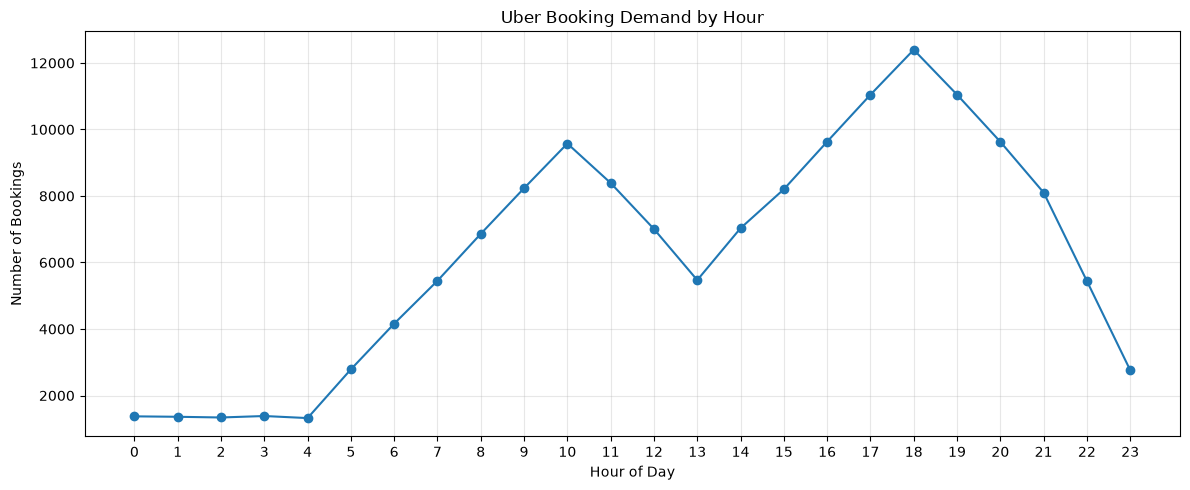

In [16]:
# ============================================
# CHART 1 — BOOKINGS BY HOUR
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand["Hour"],
    hourly_demand["Bookings"],
    marker="o"
)

plt.title("Uber Booking Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bookings")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Key takeaway:** Demand peaks at 18:00 with 12,397 bookings, making the evening period the most important demand window for capacity planning.

### 6.2 Fulfillment Performance by Hour

Comparing completion rates across hours helps determine whether periods of high demand are associated with weaker ride fulfillment.

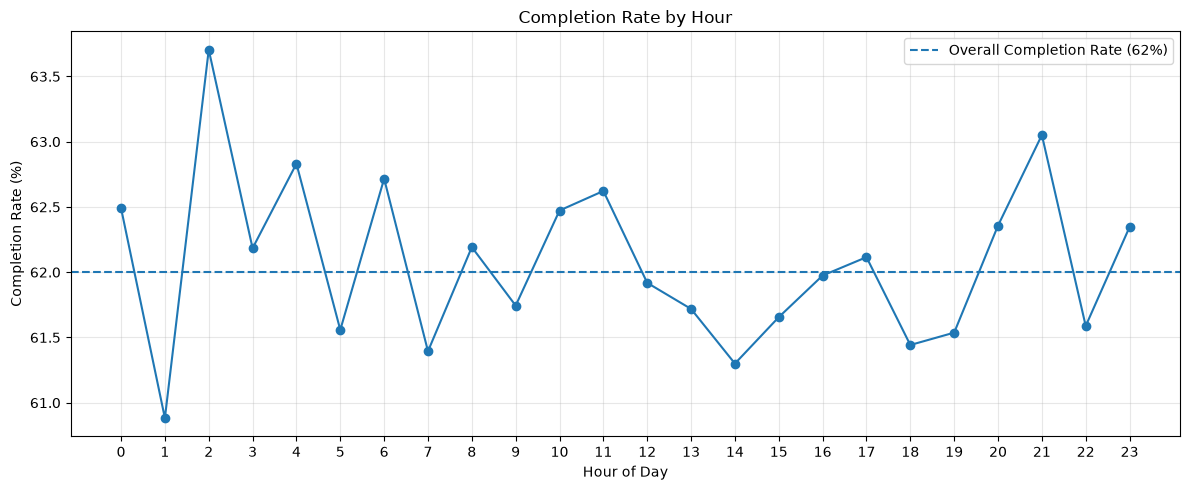

In [17]:
# ============================================
# CHART 2 — COMPLETION RATE BY HOUR
# ============================================

hourly_completion = (
    df_clean.groupby("Hour")
    .agg(
        Bookings=("Booking ID", "count"),
        Completed_Rides=("Is Completed", "sum")
    )
)

hourly_completion["Completion Rate (%)"] = (
    hourly_completion["Completed_Rides"]
    / hourly_completion["Bookings"]
    * 100
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_completion.index,
    hourly_completion["Completion Rate (%)"],
    marker="o"
)

plt.axhline(
    62,
    linestyle="--",
    label="Overall Completion Rate (62%)"
)

plt.title("Completion Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Completion Rate (%)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Key takeaway:** Completion remains close to the overall 62% rate during peak hours, indicating that fulfillment challenges are not caused by demand pressure alone.

### 6.3 Booking Outcome Breakdown

Understanding the distribution of completed and unsuccessful bookings highlights the scale and sources of fulfillment loss.

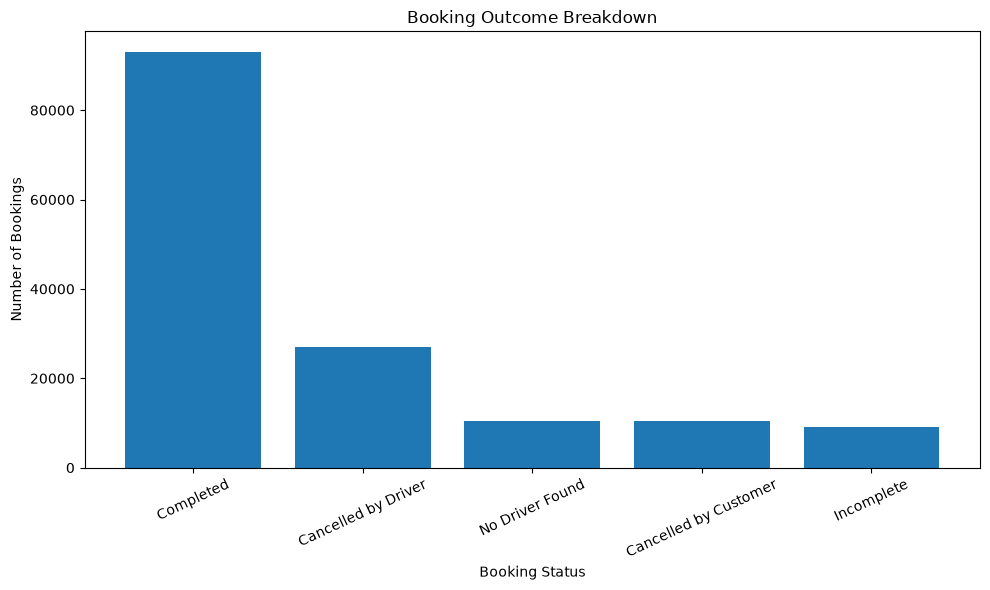

In [18]:
# ============================================
# CHART 3 — BOOKING STATUS BREAKDOWN
# ============================================

status_chart = (
    df_clean["Booking Status"]
    .value_counts()
    .reindex([
        "Completed",
        "Cancelled by Driver",
        "No Driver Found",
        "Cancelled by Customer",
        "Incomplete"
    ])
)

plt.figure(figsize=(10, 6))

plt.bar(
    status_chart.index,
    status_chart.values
)

plt.title("Booking Outcome Breakdown")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

**Key takeaway:** Only 62% of bookings are completed, while driver cancellations represent the largest source of unsuccessful bookings at 18% of total bookings.

### 6.4 Cancellation Drivers

Understanding the reasons behind customer and driver cancellations helps identify the operational issues contributing to unsuccessful bookings.

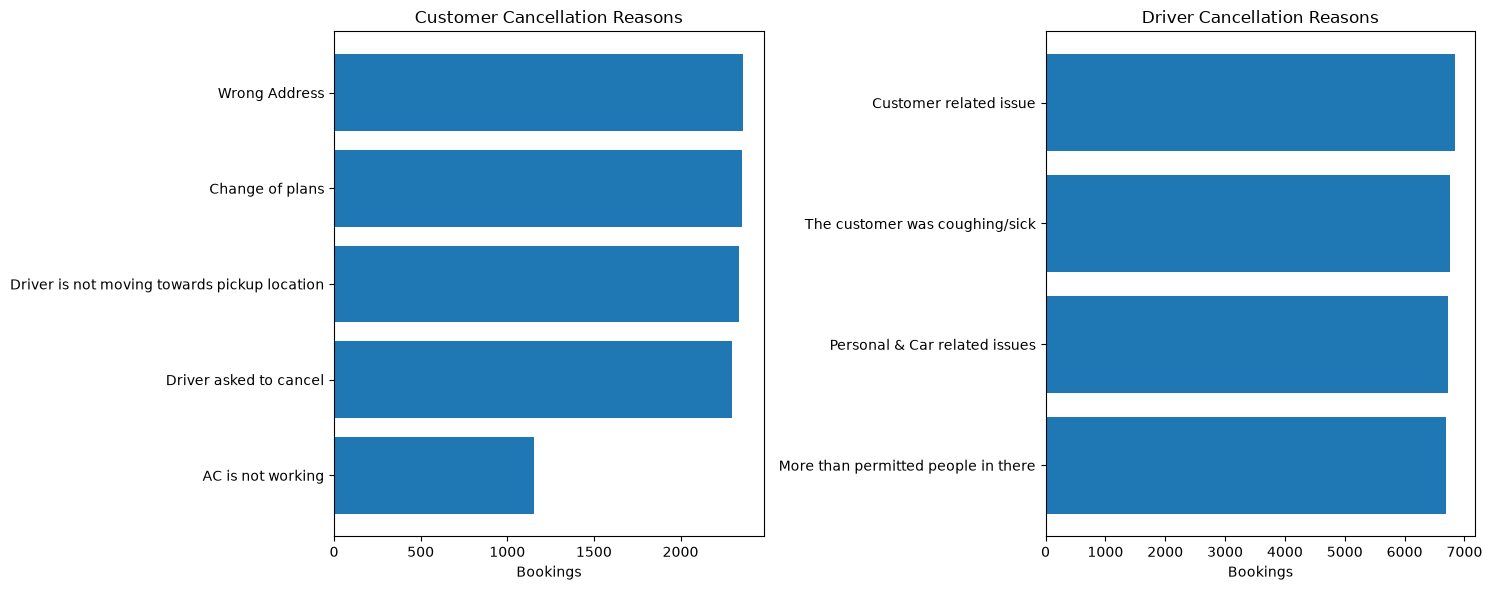

In [19]:
# ============================================
# CHART 4 — CANCELLATION REASONS
# ============================================

customer_reasons = (
    customer_cancel_reasons
    .sort_values("Bookings", ascending=True)
)

driver_reasons = (
    driver_cancel_reasons
    .sort_values("Bookings", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Customer cancellations
axes[0].barh(
    customer_reasons["Cancellation Reason"],
    customer_reasons["Bookings"]
)

axes[0].set_title("Customer Cancellation Reasons")
axes[0].set_xlabel("Bookings")

# Driver cancellations
axes[1].barh(
    driver_reasons["Cancellation Reason"],
    driver_reasons["Bookings"]
)

axes[1].set_title("Driver Cancellation Reasons")
axes[1].set_xlabel("Bookings")

plt.tight_layout()
plt.show()

**Key takeaway:** Driver cancellations occur at 18% of all bookings, substantially higher than customer cancellations at 7%. The relatively even distribution of cancellation reasons suggests that fulfillment issues are driven by multiple operational factors rather than a single dominant cause.

### 6.5 Vehicle Segment Performance

Vehicle-level comparison reveals whether certain ride categories experience weaker fulfillment despite generating comparable or higher booking value.

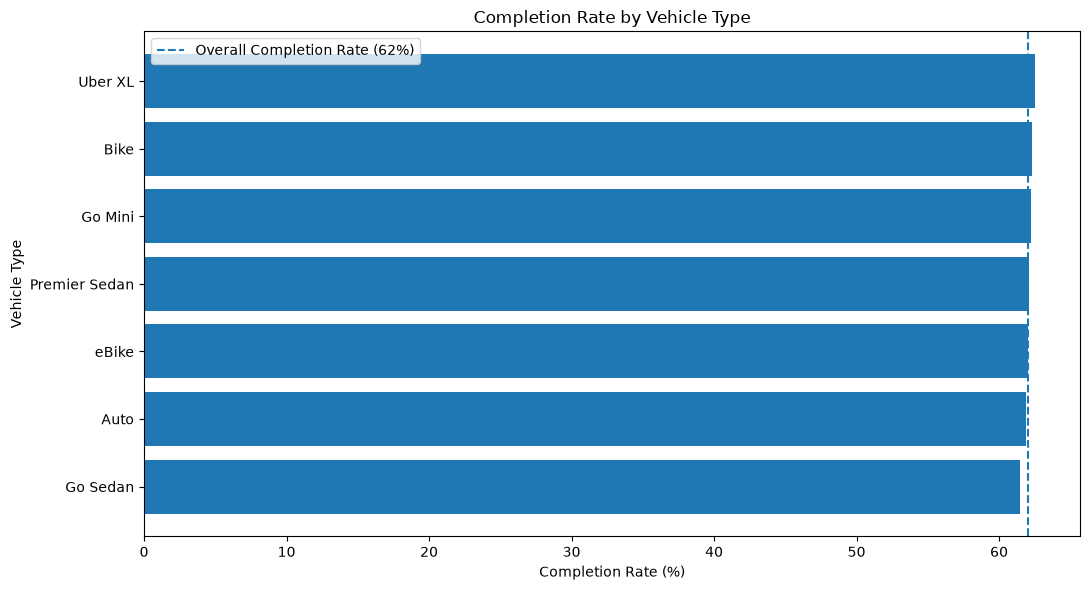

In [20]:
# ============================================
# CHART 5 — VEHICLE PERFORMANCE
# ============================================

vehicle_chart = (
    vehicle_performance
    .sort_values("Completion Rate (%)")
)

plt.figure(figsize=(11, 6))

plt.barh(
    vehicle_chart.index,
    vehicle_chart["Completion Rate (%)"]
)

plt.axvline(
    62,
    linestyle="--",
    label="Overall Completion Rate (62%)"
)

plt.title("Completion Rate by Vehicle Type")
plt.xlabel("Completion Rate (%)")
plt.ylabel("Vehicle Type")
plt.legend()

plt.tight_layout()
plt.show()

**Key takeaway:** Go Sedan has the lowest completion rate at 61.44% and the highest driver cancellation rate at 18.54%, despite having the highest average booking value at ₹512.03, making it a key segment for operational improvement.

### 6.6 Operational Risk Hotspots

A composite operational risk score is used to prioritize locations where low completion, driver cancellations, and unmet demand occur simultaneously.

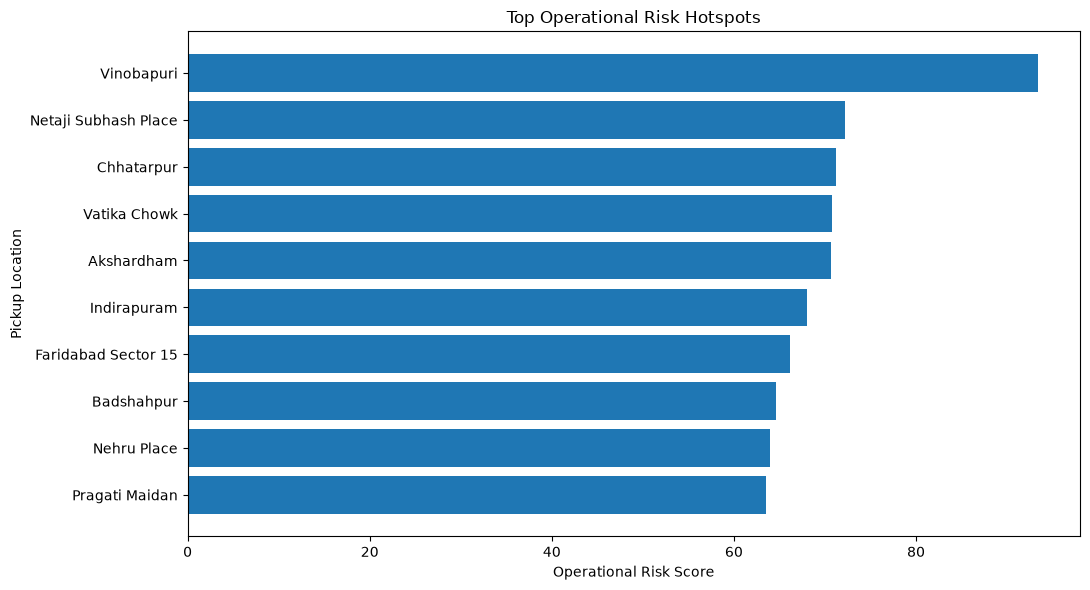

In [21]:
# ============================================
# CHART 6 — OPERATIONAL RISK HOTSPOTS
# ============================================

risk_chart = (
    risk_hotspots
    .sort_values("Operational Risk Score", ascending=True)
    .tail(10)
)

plt.figure(figsize=(11, 6))

plt.barh(
    risk_chart.index,
    risk_chart["Operational Risk Score"]
)

plt.title("Top Operational Risk Hotspots")
plt.xlabel("Operational Risk Score")
plt.ylabel("Pickup Location")

plt.tight_layout()
plt.show()

**Key takeaway:** Operational risk varies substantially across pickup locations, with Vinobapuri emerging as the highest-risk location due to its low completion rate and elevated driver-cancellation and no-driver-found rates.

### 6.7 Revenue Contribution by Vehicle Type

Comparing revenue contribution across vehicle categories helps distinguish high-volume revenue generators from segments with stronger revenue efficiency.

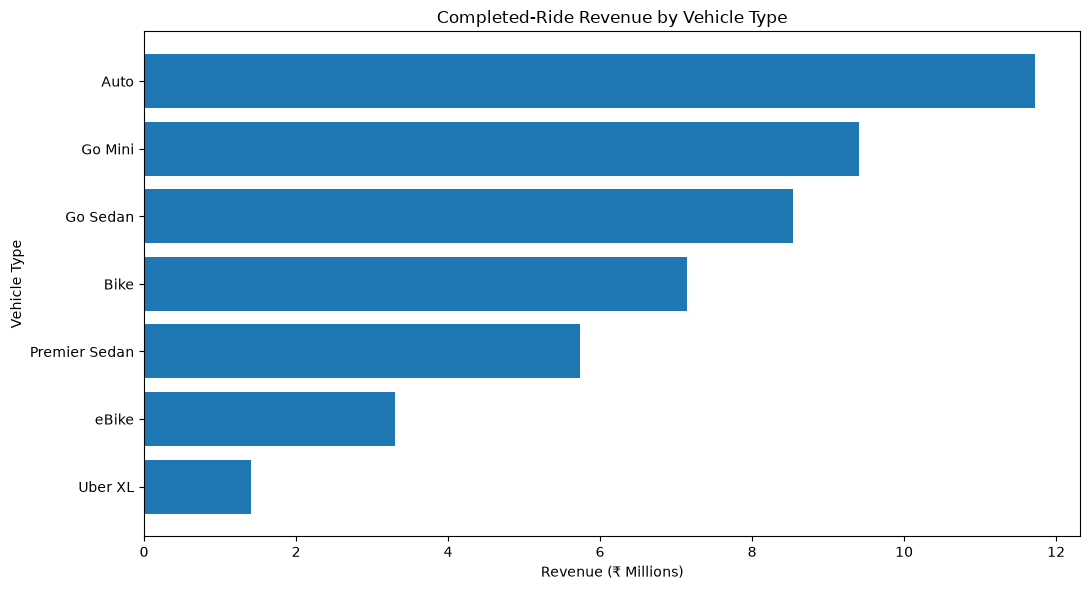

In [22]:
# ============================================
# CHART 7 — REVENUE BY VEHICLE
# ============================================

revenue_chart = (
    vehicle_revenue
    .sort_values("Total_Revenue", ascending=True)
)

plt.figure(figsize=(11, 6))

plt.barh(
    revenue_chart.index,
    revenue_chart["Total_Revenue"] / 1_000_000
)

plt.title("Completed-Ride Revenue by Vehicle Type")
plt.xlabel("Revenue (₹ Millions)")
plt.ylabel("Vehicle Type")

plt.tight_layout()
plt.show()

**Key takeaway:** Auto contributes the largest share of completed-ride revenue at 24.81%, while Go Sedan generates the highest average booking value and revenue per kilometre, indicating strong revenue efficiency despite weaker fulfillment.

# 7. Key Business Insights

### 1. Fulfillment is the primary operational challenge
Only 62% of the 150,000 bookings resulted in completed rides, leaving 38% of bookings unsuccessful. Driver cancellations are the largest contributor, accounting for 18% of all bookings.

### 2. Peak demand is not the sole cause of fulfillment loss
The 17:00–20:00 period represents 29.41% of total bookings, with a completion rate of 61.83% compared with 62.07% during off-peak hours. This indicates that the overall fulfillment gap is not driven solely by evening demand pressure.

### 3. Driver cancellations require operational attention
Driver cancellations occur at twice the rate of customer cancellations. However, driver cancellation reasons are relatively evenly distributed, suggesting that multiple operational factors contribute rather than one dominant issue.

### 4. Location-level performance reveals significant operational hotspots
Vinobapuri has the highest operational risk among the analyzed high-demand locations, with only 54.68% completion, 21.39% driver cancellations, and 9.23% no-driver-found bookings.

### 5. Go Sedan presents an interesting value-versus-fulfillment trade-off
Go Sedan generates the highest average booking value (₹512.03) and highest average revenue per kilometre (₹34.66), but has the lowest vehicle-level completion rate (61.44%) and highest driver cancellation rate (18.54%).

### 6. Revenue per kilometre is strongly influenced by outliers
Average revenue per kilometre is ₹33.86 compared with a median of ₹17.70. Extremely high values from short-distance, high-value rides significantly influence the average and should therefore be interpreted carefully.

### 7. Customer experience appears relatively stable
Average customer and driver ratings are 4.40 and 4.23 respectively, with limited variation across vehicle categories. This suggests that fulfillment and operational reliability represent larger improvement opportunities than rating performance.

# 8. Business Recommendations

### 1. Prioritize fulfillment improvement
Focus operational efforts on reducing driver cancellations and no-driver-found bookings, as these represent the largest sources of lost ride opportunities.

### 2. Investigate location-specific supply gaps
Prioritize locations such as Vinobapuri and other high-risk hotspots for driver availability analysis, incentive programs, and supply rebalancing.

### 3. Improve Go Sedan fulfillment
Go Sedan demonstrates strong revenue efficiency but relatively weak completion performance. Investigating driver cancellation patterns within this segment could unlock additional revenue without requiring significant demand growth.

### 4. Use demand patterns for proactive driver positioning
The strong evening demand concentration can be used to proactively position drivers before peak periods, even though peak demand itself does not appear to be the primary cause of fulfillment loss.

### 5. Monitor revenue efficiency using robust statistics
Because revenue per kilometre is highly skewed, median and percentile-based metrics should be monitored alongside averages to avoid decisions being distorted by extreme rides.

### 6. Focus customer-experience initiatives on operational reliability
Since ratings are already relatively strong and stable, improving ride availability and successful completion is likely to provide greater business impact than broad rating-focused interventions.

# 9. Conclusion

This analysis examined 150,000 ride-booking records to understand demand patterns, fulfillment performance, cancellation behavior, operational hotspots, revenue economics, and customer experience.

The analysis shows that the primary opportunity is not simply increasing demand, but improving the percentage of bookings that successfully convert into completed rides. Driver cancellations and location-level supply gaps emerge as key areas for operational investigation.

The combination of demand analysis, vehicle-level performance, location risk scoring, and revenue efficiency provides a data-driven framework for prioritizing operational improvements and identifying opportunities for revenue growth.